## Tarea

Explorar la relación entre la variable objetivo `default_next_month` y las variables de historial de pago:

- `PAY_1`
- `PAY_2`
- `PAY_3`
- `PAY_4`
- `PAY_5`
- `PAY_6`

### Instrucciones

Para cada variable:

1. Calcular la distribución de frecuencias de sus categorías.
2. Calcular la tasa de incumplimiento por categoría.
3. Elaborar una gráfica de barras de la tasa de incumplimiento.
4. Redactar una interpretación breve de los resultados.

Investigar qué tipo de correlación es más adecuada para el conjunto de entre variables numéricas: **Pearson** o **Spearman**.

## Solución  de la Tarea

Primero importaremos todas las librerias que se utilizaran.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importamos nuestros datos y una exploración buscando la variable que nos interesa.

In [2]:
f = "../data/default of credit card clients.xls"
df = pd.read_excel(f, header=1)

# Renombramos la columna  default payment next month a default_next_month
df = df.rename(columns={"default payment next month": "default_next_month"})

# Estadísticas descriptivas de las columnas numéricas, transpuestas para mejor visualización
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Antes de avanzar más, es importante explicar que signifca **Default Payment next month**. Esta es la variable objeto la cual nos indica si un cliente incumplió o no con el pago el mes siguiente al periodo de observación.

**PAY_1**,**PAY_2**,**PAY_3**,**PAY_4**,**PAY_5** y **PAY_6** son variables que refleja el estatus de impago en meses previos. como vismos en la exploración, no se encuentra la variable **PAY_1** por lo que la reemplazaremos por **PAY_0**.

In [3]:
# Escojemos las columnas de pago para analizar su distribución
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df[pay_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.0,0.0,0.0,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.0,0.0,0.0,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.0,0.0,0.0,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.0,0.0,0.0,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.0,0.0,0.0,8.0
PAY_6,30000.0,-0.291100,1.149988,-2.0,-1.0,0.0,0.0,8.0


Primero veremos como obtener la **Distribución de frecuencias** para la variable **PAY_0**

In [4]:
# Distribución de frecuencias de PAY_0
frecuencias_pay_0 = df["PAY_0"].value_counts().sort_index()
print("Distribución de frecuencias de PAY_0:")
print(frecuencias_pay_0)

Distribución de frecuencias de PAY_0:
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


Ahora la tasa de incumplimiento de **PAY_0**

In [5]:
# Tasa de incumplimiento por categoría de PAY_0
tasa_incumplimiento_pay_0 = df.groupby("PAY_0")["default_next_month"].mean()
print(tasa_incumplimiento_pay_0)

PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default_next_month, dtype: float64


Generamos una gráfica de barras para visualizar la tasa de incumplimiento por categoría de **PAY_0**

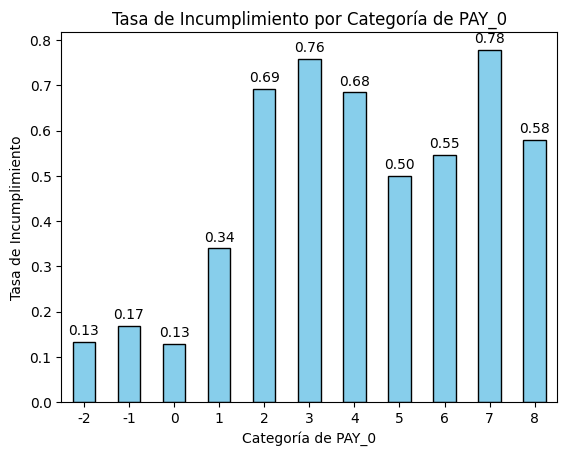

In [6]:
ax = tasa_incumplimiento_pay_0.plot(kind="bar", color="skyblue", edgecolor="black")
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
plt.title("Tasa de Incumplimiento por Categoría de PAY_0")
plt.xlabel("Categoría de PAY_0")
plt.ylabel("Tasa de Incumplimiento")
plt.xticks(rotation=0)
plt.show()

Ahora lo hacemos para todas nuestras variables **PAY_***

--- 
 ### Análisis de PAY_0 ###
Distribución de frecuencias:


PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Tasa de incumplimiento:


PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default_next_month, dtype: float64

--- 
 ### Análisis de PAY_2 ###
Distribución de frecuencias:


...

PAY_5
-2    0.196876
-1    0.161943
 0    0.188529
 2    0.541889
 3    0.634831
 4    0.607143
 5    0.588235
 6    0.750000
 7    0.827586
 8    1.000000
Name: default_next_month, dtype: float64

--- 
 ### Análisis de PAY_6 ###
Distribución de frecuencias:


PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

Tasa de incumplimiento:


PAY_6
-2    0.200409
-1    0.169861
 0    0.188444
 2    0.506508
 3    0.641304
 4    0.632653
 5    0.538462
 6    0.736842
 7    0.826087
 8    1.000000
Name: default_next_month, dtype: float64

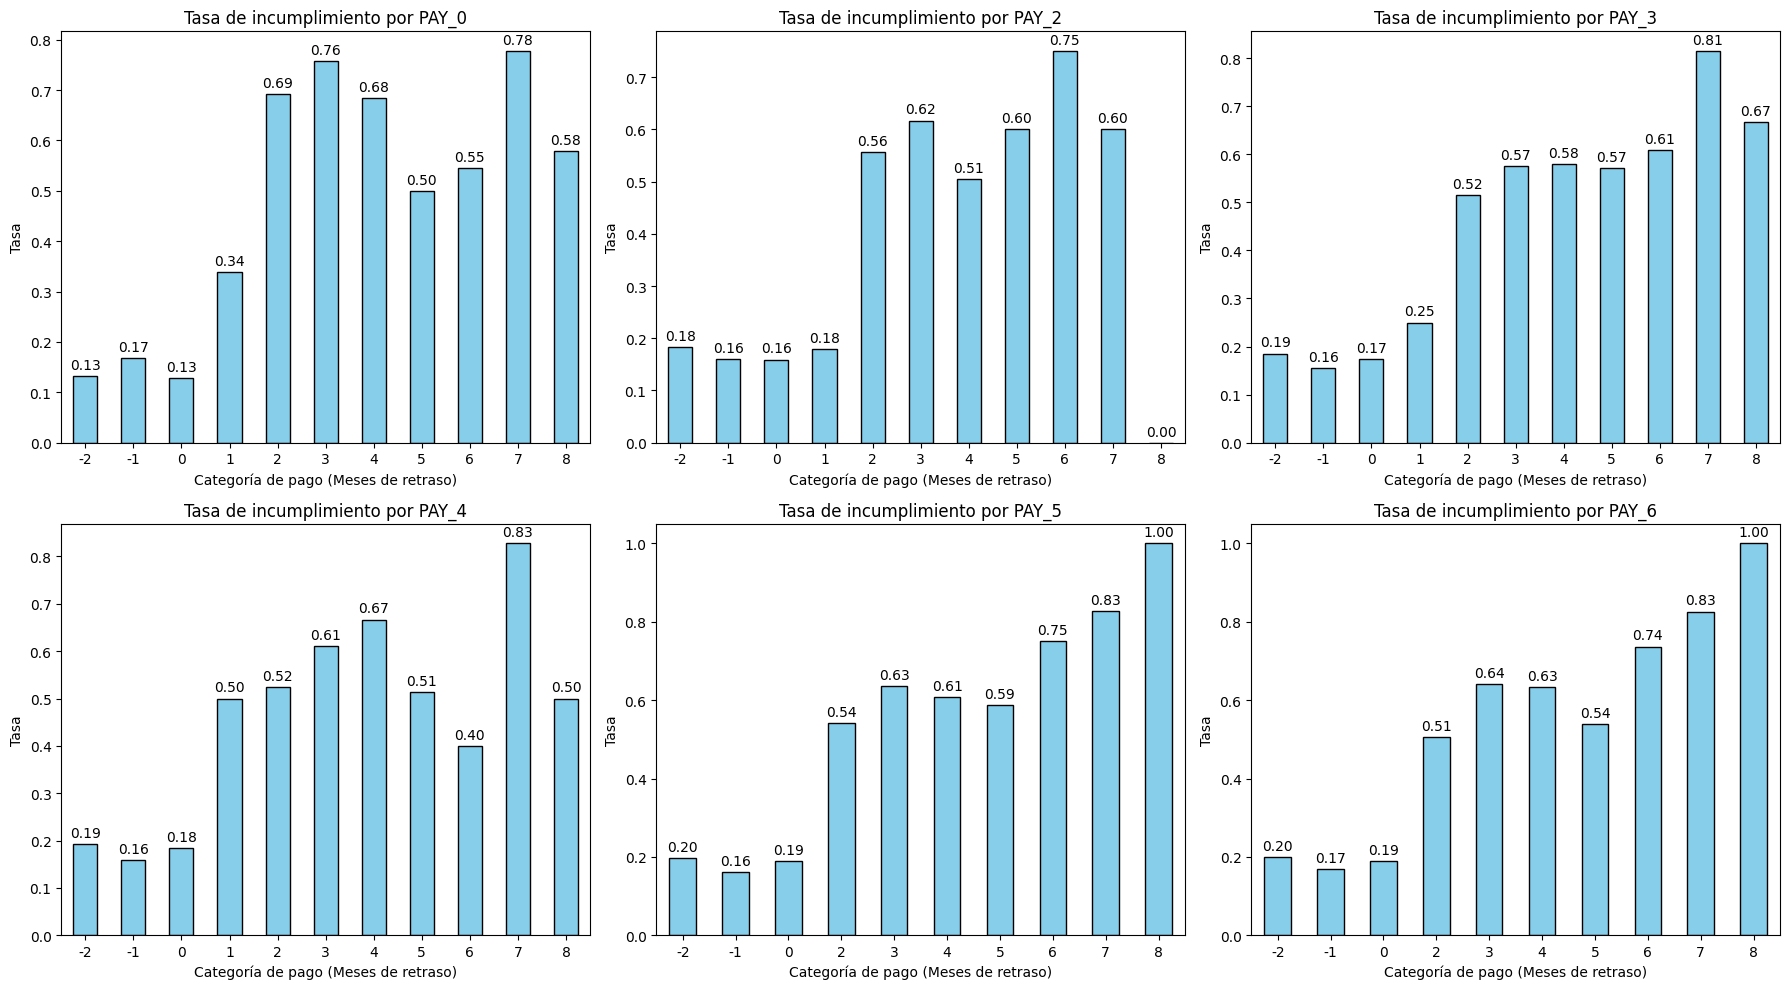

In [7]:
# 1. Creamos la figura y la cuadrícula ANTES del for
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Aplanamos para recorrerla fácilmente

# 2. Lista con los nombres de tus columnas de pago en minúsculas
for i, var in enumerate(pay_cols):
    
    # Un pequeño título visual para separar los resultados de cada variable en tu notebook
    print(f"--- \n ### Análisis de {var} ###")
    
    # Distribución de frecuencias
    print("Distribución de frecuencias:")
    frecuencias = df[var].value_counts().sort_index()
    display(frecuencias)
    
    # Tasa de incumplimiento por categoría
    print("Tasa de incumplimiento:")
    tasa_incumplimiento = df.groupby(var)['default_next_month'].mean()
    display(tasa_incumplimiento)
    
    # Gráfica de barras (OJO: Aquí le decimos que se guarde en axes[i])
    tasa_incumplimiento.plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[i])
    
    axes[i].bar_label(axes[i].containers[0], fmt='%.2f', padding=3)
    axes[i].set_title(f'Tasa de incumplimiento por {var}')
    axes[i].set_xlabel('Categoría de pago (Meses de retraso)')
    axes[i].set_ylabel('Tasa')
    axes[i].tick_params(axis='x', rotation=0)

# 3. Una vez que termina el for, mostramos TODAS las gráficas juntas
plt.tight_layout()
plt.show()

### Interpretación de los datos obtenidos

Para comprender los resultados de este análisis, es fundamental recordar que estamos trabajando con una base de datos de 30,000 usuarios de un banco. De toda la información disponible, nos estamos enfocando en las variables del historial de pago (**PAY_0**, **PAY_2**, **PAY_3**, **PAY_4**, **PAY_5** y **PAY_6**), las cuales nos indican el comportamiento de los clientes mes a mes.

* **¿Qué significan los valores de PAY?** Estas variables indican si los clientes pagaron o no en ese mes y cuántos meses de atraso tienen. Por ejemplo: un valor de `-1` o `0` significa que el cliente pagó a tiempo o está al corriente. Los demás números positivos (`1, 2, 3...`) indican los meses exactos de retraso en el pago.

* **Distribución de frecuencias:** Al calcular esto, estamos cuantificando exactamente cuántos clientes pagaron a tiempo y cuántos presentan cada nivel de atraso en un mes determinado. Nos permite ver el volumen de personas en cada situación.

* **Tasa de incumplimiento:** Este cálculo cruza la información de los clientes en **PAY** con los datos de nuestra variable objetivo (**default_payment_next_month**). Básicamente, nos dice, de todos los clientes que estaban en una misma situación de pago (por ejemplo, con 2 meses de atraso), qué porcentaje de ellos terminó sin pagar (incumplió) al mes siguiente.

### La lógica detrás de la predicción en el tiempo

Pensemoslo como un problema de cinemática o la trayectoria de una partícula. Tu única variable objetivo es el punto de impacto final en el tiempo $t$ (eso es nuestra variable `default_payment_next_month`). Para intentar predecir ese impacto, el banco tomó mediciones del comportamiento del cliente en 6 momentos anteriores ($t-1, t-2, \dots, t-6$).

Vamos a ponerle meses reales para que sea más fácil de visualizar:

* **Tu variable objetivo (`default_payment_next_month`):** Es el futuro. ¿El cliente nos va a dejar de pagar ahorita en **Octubre**? Solo hay un resultado final (1 = no paga, 0 = sí paga).
* **`PAY_0` (Tiempo $t-1$):** Su comportamiento en **Septiembre**.
* **`PAY_2` (Tiempo $t-2$):** Su comportamiento en **Agosto**.
* ... y así hasta **`PAY_6` (Tiempo $t-6$)**, que sería su comportamiento en **Abril**.

#### ¿Por qué comparamos Abril (`PAY_6`) con el resultado de Octubre (Default)?

No lo hacemos para ver si la cuenta cuadró en Abril. Lo hacemos para **buscar patrones de riesgo a largo plazo**.

La pregunta exacta que nos estamos haciendo al calcular esa tasa de incumplimiento es: 

> *"Oye, si un cliente ya venía arrastrando un atraso de 2 meses desde hace medio año (en Abril)... ¿qué tanta probabilidad hay de que el problema haya ido creciendo y termine explotando (incumpliendo) ahorita en Octubre?"*

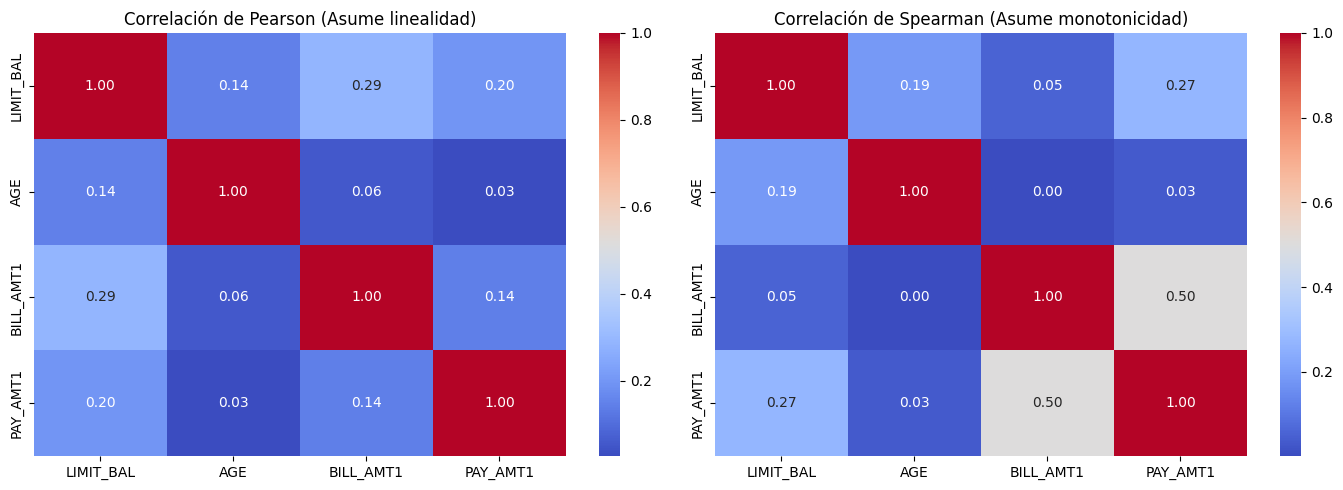

In [9]:
# Seleccionamos algunas variables numéricas clave para la demostración
cols_numericas = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

# Calculamos ambas matrices
corr_pearson = df[cols_numericas].corr(method='pearson')
corr_spearman = df[cols_numericas].corr(method='spearman')

# Creamos una figura con dos subgráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa de calor para Pearson
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Correlación de Pearson (Asume linealidad)')

# Mapa de calor para Spearman
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlación de Spearman (Asume monotonicidad)')

plt.tight_layout()
plt.show()

### Conclusión: ¿Pearson o Spearman?

Para este conjunto de datos financieros, la correlación más adecuada es la de **Spearman**, por las siguientes dos razones fundamentales:

1. **Resistencia a valores atípicos (Outliers):** Las variables monetarias de este dataset, como el límite de crédito (`limit_bal`) o los montos facturados (`bill_amt`), no tienen una distribución normal; están fuertemente sesgadas y contienen valores extremos (clientes con líneas de crédito o deudas altísimas). **Pearson** asume relaciones lineales exactas y se distorsiona fuertemente por estos valores atípicos. **Spearman**, al evaluar el *rango* o posición relativa de los datos, neutraliza el impacto de los valores extremos.
2. **Naturaleza ordinal de los datos:** Las variables del historial de pago (`pay_0` a `pay_6`) representan categorías ordenadas (meses de retraso), no valores numéricos continuos. **Spearman** está diseñado matemáticamente para capturar relaciones monotónicas en este tipo de variables ordinales, lo cual **Pearson** no puede hacer de forma precisa.